# FIFA WC 2026 DATASET 

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [70]:
df = pd.read_csv(r"C:\Abhishree\Projects_GitHubLinked\datasets\Titanic\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [71]:
df.shape

(891, 12)

In [72]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [76]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


Step 1 : what does one row represent?

In [77]:
""" 
Each row represents the information of the one passenger.
"""

' \nEach row represents the information of the one passenger.\n'


Step 2 : Think about missing values. ( don't think how do I fill these.) 
why might someone's AGE be missing? could the recorder have 
* forgotten it?
* not known it?
* intentionally left it blank?
is age an important feature?

In [78]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


<Axes: xlabel='Age', ylabel='Count'>

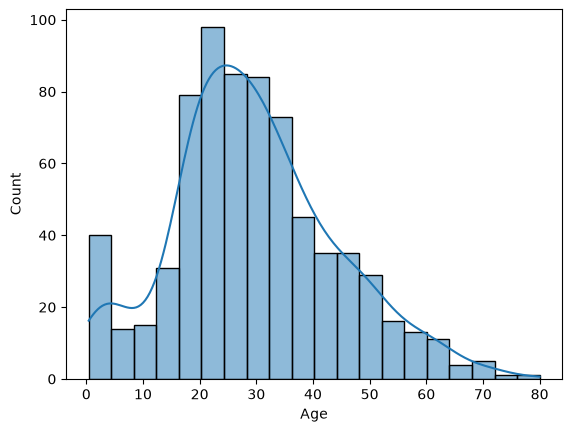

In [79]:
sns.histplot(df['Age'],kde=True)

In [80]:
# I want to extract Mr , Mrs from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.',expand=False) 
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [81]:
df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
df['Title'] = df['Title'].replace('Mme','Ms')
df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')

In [82]:
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       125
Master     40
Rare       23
Ms          1
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='Age'>

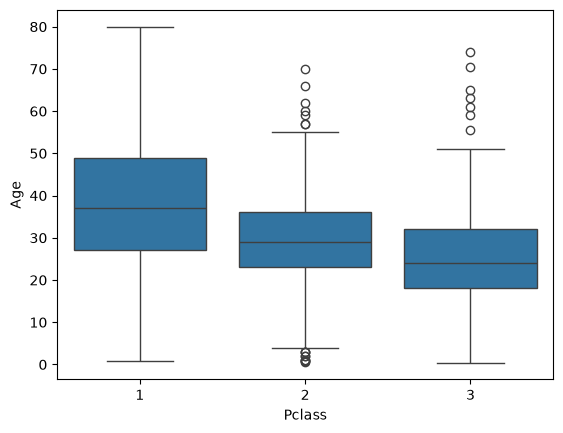

In [83]:
sns.boxplot(y=df['Age'], x= df['Pclass'])

<Axes: xlabel='Title', ylabel='Age'>

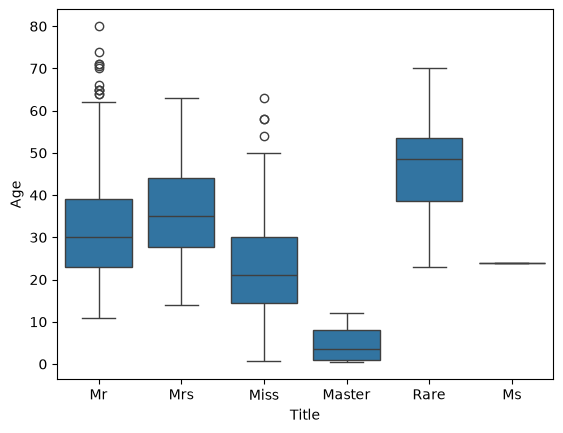

In [84]:
sns.boxplot(y = df['Age'], x = df['Title'])

<Axes: xlabel='Age', ylabel='Count'>

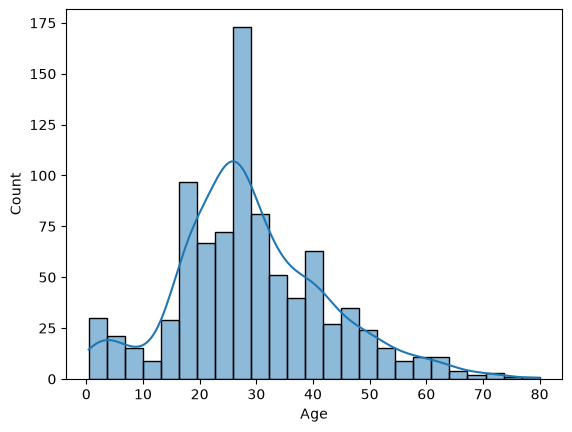

In [85]:
# calculating the median age for each title group and use it to fill the missing values in Age
# Make sure to run this on a freshly loaded dataframe!
df['Age'] = df['Age'].fillna(df.groupby(['Title','Pclass'])['Age'].transform('median'))
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
df['Age'] = df['Age'].fillna(df['Age'].median())
# Now plot it!
sns.histplot(df['Age'], kde=True)

CABIN: 687 out of 891 values are missing. 
should we keep it? drop it? investigate it first? 

In [86]:
# CABIN HAS SOME NULL VALUES.
df['Cabin'].isnull().mean() *100
# 77% missing values. 
# if we fill we will be making things up, so let's drop it entirely.
# before droppping lets take out the useful information and then drop.
df['Cabin'].head(15)
#  useful info is the C deck G deck.

0      NaN
1      C85
2      NaN
3     C123
4      NaN
5      NaN
6      E46
7      NaN
8      NaN
9      NaN
10      G6
11    C103
12     NaN
13     NaN
14     NaN
Name: Cabin, dtype: str

In [87]:
df['Deck'] = df['Cabin'].str[0]
df['Deck']

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: Deck, Length: 891, dtype: str

In [88]:
df['Deck'] = df['Deck'].fillna('Unknown')

In [89]:
df.drop(columns= 'Cabin', inplace=True)

In [90]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,Unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Rare,Unknown
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,18.0,1,2,W./C. 6607,23.4500,S,Miss,Unknown
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Mr,C


EMBARKED: only 2 values are missing. 
* Delete those 2 rows? 
* fill them?
* ignore them?

In [91]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 

In [92]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
Deck           0
dtype: int64

In [93]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Step 3: Ask Does this makes sense?

df.describe(include='all') read them thoroughly 
Questions to answer:

* Which sex appears more often?
* Which passenger class appears most?
* Which embarkation port appears most?
* What is the highest fare?
* Does anything surprise you?

Step 4: BUILD CURIOSITY
predict answers before writing any code. 
1. Do you think men survived more or women?
2. Rich passengers or poor passengers?
3. Children or adults? 
Write guesses first then test with pandas. 